In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from prb_episode_runner import PRBEnvWrapper
from prb_skill_executer import PRBSkillExecuter
from PIL import Image
import numpy as np

env = PRBEnvWrapper(3, 5)

In [27]:
env.reset()

checking GPU availability
GPU available: False
Renderer is listening for requests on port 49505


rendering
sending request
awaiting response
Blender 2.83.2 (hash 239fbf7d936f built 2020-07-09 06:21:45)
found bundled python: /home/guy.azran/workspace/semantic_state_estimator/examples/prb/photorealistic_blocksworld/blender-2.83.2-linux64/2.83/python
Read blend: /home/guy.azran/workspace/semantic_state_estimator/examples/prb/photorealistic_blocksworld/data/base_scene.blend
Info: Deleted 1 object(s)
Fra:1 Mem:34.12M (0.00M, Peak 34.23M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | Ground
Fra:1 Mem:34.22M (0.00M, Peak 34.23M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCylinder_0
Fra:1 Mem:39.18M (0.00M, Peak 39.18M) | Time:00:00.05 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCylinder_1


numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int()

Fra:1 Mem:44.14M (0.00M, Peak 44.14M) | Time:00:00.06 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCube_v2_0
Fra:1 Mem:44.69M (0.00M, Peak 44.69M) | Time:00:00.06 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCube_v2_1
Fra:1 Mem:45.18M (0.00M, Peak 45.18M) | Time:00:00.06 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCube_v2_2
Fra:1 Mem:45.67M (0.00M, Peak 45.67M) | Time:00:00.06 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Initializing
Fra:1 Mem:35.24M (0.00M, Peak 45.67M) | Time:00:00.06 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Waiting for render to start
Fra:1 Mem:35.24M (0.00M, Peak 45.67M) | Time:00:00.06 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Loading render kernels (may take a few minutes the first time)
Fra:1 Mem:35.24M (0.00M, Peak 45.67M) | Time:00:00.06 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Updating Scene
Fra:1 Mem:35.24M (0.00M, Peak 45.67M) | Time:00:00.06 | M

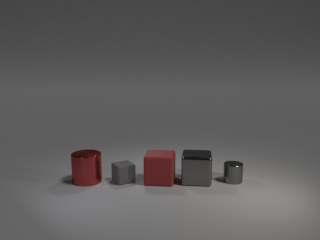

In [28]:
img1 = env.render()
Image.fromarray(img1)

In [31]:
pilimg = Image.fromarray(img1)

In [44]:
np.all(img1[:, :, 3] == 255)

True

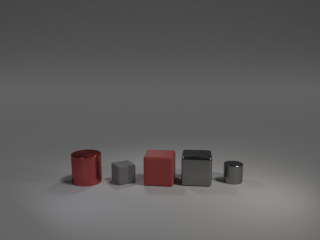

In [46]:
pilimg.convert('RGB').convert('RGB').convert('RGB')

In [5]:
exec = PRBSkillExecuter(env)

In [6]:
print(env.get_problem_file_str())

(define (problem shape-stacking)
    (:domain shape-stacking)
    (:objects
        large-red-metal-sphere small-red-metal-sphere - sphere
small-red-rubber-cube large-red-rubber-cylinder - block
    )

    (:init)
    (:goal (and))
)



In [7]:
exec.execute_action('move-from-table-to-block', ['small-red-rubber-cube', 'large-red-rubber-cylinder'])

the problem:
problem name = shape-stacking

types = [shape, block - shape, sphere - shape]

fluents = [
  bool is-directly-on-table[s=shape]
  bool is-clear-on-top[s=shape]
  bool shape-on-top-of-block[s=shape, b=block - shape]
]

actions = [
  action move-from-block-to-table(shape s, block - shape b) {
    preconditions = [
      (is-clear-on-top(s) and shape-on-top-of-block(s, b))
    ]
    effects = [
      is-directly-on-table(s) := true
      shape-on-top-of-block(s, b) := false
      is-clear-on-top(b) := true
    ]
  }
  action move-from-table-to-block(shape s, block - shape b) {
    preconditions = [
      (is-clear-on-top(s) and is-directly-on-table(s) and is-clear-on-top(b) and (not (s == b)))
    ]
    effects = [
      is-directly-on-table(s) := false
      is-clear-on-top(b) := false
      shape-on-top-of-block(s, b) := true
    ]
  }
  action move-from-block-to-block(shape s, block - shape b1, block - shape b2) {
    preconditions = [
      (is-clear-on-top(s) and shape-o

(True, [])

rendering
sending request
awaiting response
Read blend: /home/guy.azran/workspace/semantic_state_estimator/examples/prb/photorealistic_blocksworld/data/base_scene.blend
Info: Deleted 1 object(s)
Fra:1 Mem:31.39M (0.00M, Peak 31.50M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | Ground
Fra:1 Mem:31.49M (0.00M, Peak 31.50M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCube_v2_0
Fra:1 Mem:31.99M (0.00M, Peak 31.99M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | Sphere_0
Fra:1 Mem:34.24M (0.00M, Peak 34.24M) | Time:00:00.05 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCylinder_0
Fra:1 Mem:38.66M (0.00M, Peak 38.66M) | Time:00:00.06 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | Sphere_1
Fra:1 Mem:40.92M (0.00M, Peak 40.92M) | Time:00:00.07 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Initializing
Fra:1 Mem:31.

numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int()

Fra:1 Mem:42.46M (0.00M, Peak 42.46M) | Time:00:00.18 | Mem:0.47M, Peak:0.47M | Scene, RenderLayer | Updating Scene BVH | Packing BVH triangles and strands
Fra:1 Mem:49.75M (0.00M, Peak 49.75M) | Time:00:00.19 | Mem:0.47M, Peak:0.47M | Scene, RenderLayer | Updating Scene BVH | Packing BVH nodes
Fra:1 Mem:46.06M (0.00M, Peak 52.31M) | Time:00:00.19 | Mem:0.47M, Peak:0.47M | Scene, RenderLayer | Updating Scene BVH | Copying BVH to device
Fra:1 Mem:46.58M (0.00M, Peak 52.31M) | Time:00:00.19 | Mem:11.89M, Peak:11.89M | Scene, RenderLayer | Updating Mesh | Computing normals
Fra:1 Mem:51.33M (0.00M, Peak 52.31M) | Time:00:00.20 | Mem:11.89M, Peak:11.89M | Scene, RenderLayer | Updating Mesh | Copying Mesh to device
Fra:1 Mem:50.81M (0.00M, Peak 52.31M) | Time:00:00.20 | Mem:16.63M, Peak:16.63M | Scene, RenderLayer | Updating Objects Flags
Fra:1 Mem:50.81M (0.00M, Peak 52.31M) | Time:00:00.20 | Mem:16.63M, Peak:16.63M | Scene, RenderLayer | Updating Images
Fra:1 Mem:50.81M (0.00M, Peak 52.31M

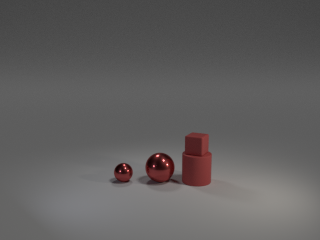

In [8]:
img2 = env.render()
Image.fromarray(img2)

In [19]:
exec.execute_action('move-from-table-to-block', ['small-red-rubber-cube', 'large-red-rubber-cylinder'])

Action move-from-table-to-block(small-red-rubber-cube,large-red-rubber-cylinder) is not applicable in state:
{
	is-directly-on-table(large-red-metal-sphere): True
	is-directly-on-table(small-red-metal-sphere): True
	is-directly-on-table(small-red-rubber-cube): False
	is-directly-on-table(large-red-rubber-cylinder): True
	is-clear-on-top(large-red-metal-sphere): True
	is-clear-on-top(small-red-metal-sphere): True
	is-clear-on-top(small-red-rubber-cube): True
	is-clear-on-top(large-red-rubber-cylinder): False
	shape-on-top-of-block(large-red-metal-sphere,small-red-rubber-cube): False
	shape-on-top-of-block(small-red-metal-sphere,small-red-rubber-cube): False
	shape-on-top-of-block(small-red-rubber-cube,small-red-rubber-cube): False
	shape-on-top-of-block(large-red-rubber-cylinder,small-red-rubber-cube): False
	shape-on-top-of-block(large-red-metal-sphere,large-red-rubber-cylinder): False
	shape-on-top-of-block(small-red-metal-sphere,large-red-rubber-cylinder): False
	shape-on-top-of-bloc

(False, [])

rendering
sending request
awaiting response
Read blend: /home/guy.azran/workspace/semantic_state_estimator/examples/prb/photorealistic_blocksworld/data/base_scene.blend
Info: Deleted 1 object(s)
Fra:1 Mem:31.44M (0.00M, Peak 31.55M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | Ground
Fra:1 Mem:31.54M (0.00M, Peak 31.55M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCube_v2_0
Fra:1 Mem:32.03M (0.00M, Peak 32.03M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | Sphere_0
Fra:1 Mem:34.29M (0.00M, Peak 34.29M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCylinder_0
Fra:1 Mem:38.71M (0.00M, Peak 38.71M) | Time:00:00.05 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | Sphere_1
Fra:1 Mem:40.96M (0.00M, Peak 40.96M) | Time:00:00.05 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Initializing
Fra:1 Mem:31.

numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int()

Fra:1 Mem:42.50M (0.00M, Peak 42.50M) | Time:00:00.14 | Mem:0.47M, Peak:0.47M | Scene, RenderLayer | Updating Scene BVH | Packing BVH triangles and strands
Fra:1 Mem:49.79M (0.00M, Peak 49.79M) | Time:00:00.14 | Mem:0.47M, Peak:0.47M | Scene, RenderLayer | Updating Scene BVH | Packing BVH nodes
Fra:1 Mem:46.08M (0.00M, Peak 52.33M) | Time:00:00.15 | Mem:0.47M, Peak:0.47M | Scene, RenderLayer | Updating Scene BVH | Copying BVH to device
Fra:1 Mem:46.60M (0.00M, Peak 52.33M) | Time:00:00.15 | Mem:11.86M, Peak:11.86M | Scene, RenderLayer | Updating Mesh | Computing normals
Fra:1 Mem:51.35M (0.00M, Peak 52.33M) | Time:00:00.15 | Mem:11.86M, Peak:11.86M | Scene, RenderLayer | Updating Mesh | Copying Mesh to device
Fra:1 Mem:50.83M (0.00M, Peak 52.33M) | Time:00:00.15 | Mem:16.61M, Peak:16.61M | Scene, RenderLayer | Updating Objects Flags
Fra:1 Mem:50.83M (0.00M, Peak 52.33M) | Time:00:00.15 | Mem:16.61M, Peak:16.61M | Scene, RenderLayer | Updating Images
Fra:1 Mem:50.83M (0.00M, Peak 52.33M

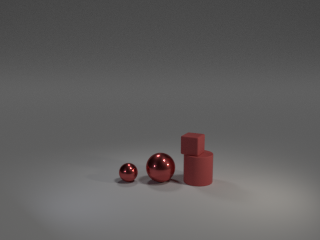

In [20]:
img3 = env.render()
Image.fromarray(img3)

In [21]:
np.all(img2 == img3)

False

In [22]:
exec.execute_action('move-from-table-to-block', ['large-red-metal-sphere', 'large-red-rubber-cylinder'])

Action move-from-table-to-block(large-red-metal-sphere,large-red-rubber-cylinder) is not applicable in state:
{
	is-directly-on-table(large-red-metal-sphere): True
	is-directly-on-table(small-red-metal-sphere): True
	is-directly-on-table(small-red-rubber-cube): False
	is-directly-on-table(large-red-rubber-cylinder): True
	is-clear-on-top(large-red-metal-sphere): True
	is-clear-on-top(small-red-metal-sphere): True
	is-clear-on-top(small-red-rubber-cube): True
	is-clear-on-top(large-red-rubber-cylinder): False
	shape-on-top-of-block(large-red-metal-sphere,small-red-rubber-cube): False
	shape-on-top-of-block(small-red-metal-sphere,small-red-rubber-cube): False
	shape-on-top-of-block(small-red-rubber-cube,small-red-rubber-cube): False
	shape-on-top-of-block(large-red-rubber-cylinder,small-red-rubber-cube): False
	shape-on-top-of-block(large-red-metal-sphere,large-red-rubber-cylinder): False
	shape-on-top-of-block(small-red-metal-sphere,large-red-rubber-cylinder): False
	shape-on-top-of-blo

(False, [])

rendering
sending request
awaiting response
Read blend: /home/guy.azran/workspace/semantic_state_estimator/examples/prb/photorealistic_blocksworld/data/base_scene.blend
Info: Deleted 1 object(s)
Fra:1 Mem:31.48M (0.00M, Peak 31.60M) | Time:00:00.03 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | Ground
Fra:1 Mem:31.59M (0.00M, Peak 31.60M) | Time:00:00.03 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCube_v2_0
Fra:1 Mem:32.08M (0.00M, Peak 32.08M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | Sphere_0
Fra:1 Mem:34.34M (0.00M, Peak 34.34M) | Time:00:00.04 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | SmoothCylinder_0
Fra:1 Mem:38.75M (0.00M, Peak 38.75M) | Time:00:00.05 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Synchronizing object | Sphere_1
Fra:1 Mem:41.01M (0.00M, Peak 41.01M) | Time:00:00.05 | Mem:0.00M, Peak:0.00M | Scene, RenderLayer | Initializing
Fra:1 Mem:31.

numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int() failed: Invalid argument
numa_sched_setaffinity_v2_int()

Fra:1 Mem:42.55M (0.00M, Peak 42.55M) | Time:00:00.15 | Mem:0.47M, Peak:0.47M | Scene, RenderLayer | Updating Scene BVH | Packing BVH triangles and strands
Fra:1 Mem:49.84M (0.00M, Peak 49.84M) | Time:00:00.15 | Mem:0.47M, Peak:0.47M | Scene, RenderLayer | Updating Scene BVH | Packing BVH nodes
Fra:1 Mem:46.07M (0.00M, Peak 52.32M) | Time:00:00.16 | Mem:0.47M, Peak:0.47M | Scene, RenderLayer | Updating Scene BVH | Copying BVH to device
Fra:1 Mem:46.59M (0.00M, Peak 52.32M) | Time:00:00.16 | Mem:11.80M, Peak:11.80M | Scene, RenderLayer | Updating Mesh | Computing normals
Fra:1 Mem:51.33M (0.00M, Peak 52.32M) | Time:00:00.16 | Mem:11.80M, Peak:11.80M | Scene, RenderLayer | Updating Mesh | Copying Mesh to device
Fra:1 Mem:50.81M (0.00M, Peak 52.32M) | Time:00:00.16 | Mem:16.54M, Peak:16.54M | Scene, RenderLayer | Updating Objects Flags
Fra:1 Mem:50.81M (0.00M, Peak 52.32M) | Time:00:00.16 | Mem:16.54M, Peak:16.54M | Scene, RenderLayer | Updating Images
Fra:1 Mem:50.81M (0.00M, Peak 52.32M

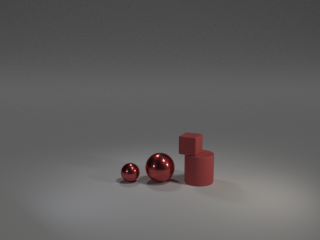

In [23]:
img4 = env.render()
Image.fromarray(img4)

In [24]:
np.all(img3 == img4)

False